# Deep Learning Fundamentals Experimental Suite

This notebook presents the executed evidence for **Step 011.1**. It covers
Problems 1–10 from the Deep Learning Fundamentals exercise using the
project's integrated automotive-part image–text dataset.

The experiments use only the committed train and validation splits. The
locked test split is not loaded, inspected, scored, or used for selection.


## Mathematical setup

For an image–text pair \((I, T)\), the model estimates a three-class
probability vector

\[
p_\theta(y\mid I,T)=\operatorname{softmax}(f_\theta(I,T)),
\]

and minimizes sparse categorical cross-entropy

\[
\mathcal{L}(\theta)=-\frac{1}{N}\sum_{i=1}^{N}
\log p_\theta(y_i\mid I_i,T_i).
\]

The primary validation metric is Macro F1 so every relation class contributes
equally to the comparison.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
REPORT_ROOT = PROJECT_ROOT / "reports" / "course_coverage" / "fundamentals"
print("Runtime: project virtual environment")
print("Working directory: repository root")


Runtime: project virtual environment
Working directory: repository root


## FND-001 and FND-002 — Data inspection and batch contract


,samples,images,groups,categories,label_distribution,source_distribution,text_length_tokens,image_pixels_24x24_rgb
train,180,60,60,10,"{'MATCH': 60, 'PARTIAL_MATCH': 60, 'MISMATCH':...","{'generated_development': 90, 'wikimedia_commo...","{'minimum': 2, 'maximum': 4, 'mean': 3.1, 'med...","{'minimum': 1.0, 'maximum': 255.0, 'mean': 167..."
validation,60,20,20,10,"{'MATCH': 20, 'PARTIAL_MATCH': 20, 'MISMATCH':...","{'generated_development': 30, 'wikimedia_commo...","{'minimum': 2, 'maximum': 4, 'mean': 3.1, 'med...","{'minimum': 0.0, 'maximum': 255.0, 'mean': 169..."


{
  "experiment_id": "FND-002",
  "status": "COMPLETED",
  "batch_size": 16,
  "train_image_shape": [
    16,
    24,
    24,
    3
  ],
  "train_text_shape": [
    16,
    12
  ],
  "train_label_shape": [
    16
  ],
  "image_dtype": "float32",
  "text_dtype": "int32",
  "label_dtype": "int32",
  "image_floating_point_reason": "Floating-point inputs support scaling, gradients, and neural-network arithmetic.",
  "integer_target_reason": "Sparse categorical cross-entropy expects integer class indices.",
  "train_shuffle": true,
  "validation_shuffle": false,
  "train_shuffle_reproducible": true,
  "validation_order_stable": true,
  "image_text_label_alignment_pass": true,
  "locked_test_csv_files_opened": false,
  "test_split_used": false,
  "final_test_evaluation_authorized": false,
  "production_final_model_changed": false
}


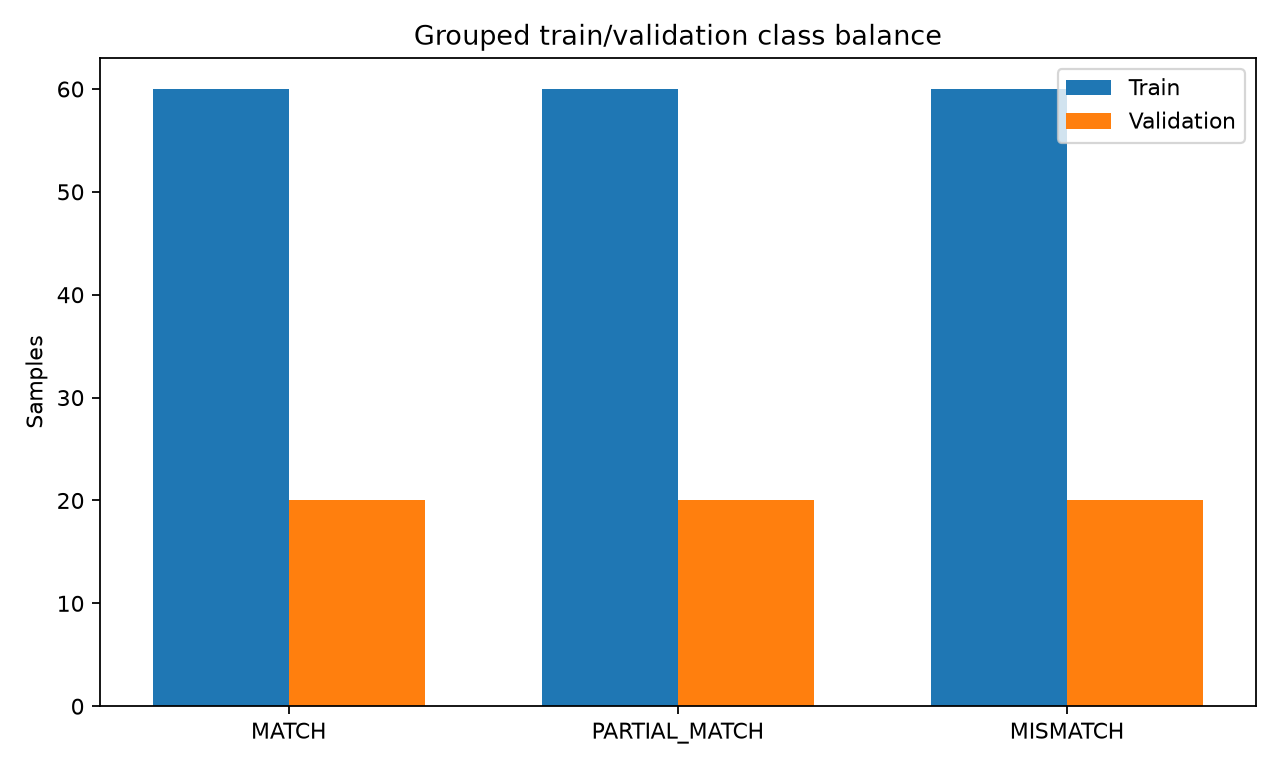

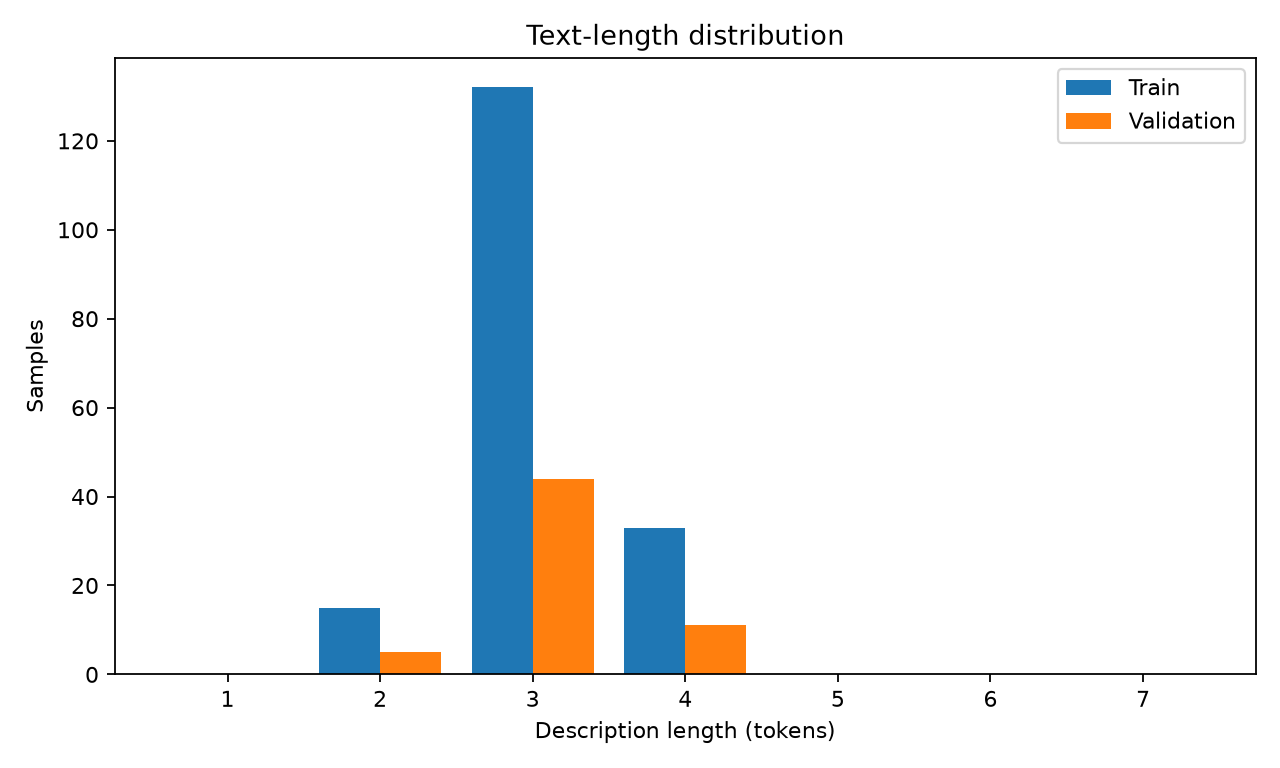

In [2]:
profile = json.loads((REPORT_ROOT / "dataset_profile.json").read_text())
batch = json.loads((REPORT_ROOT / "batch_contract.json").read_text())
display(pd.DataFrame([profile["train"], profile["validation"]], index=["train", "validation"]))
print(json.dumps(batch, indent=2))
display(Image(filename=str(REPORT_ROOT / "figures" / "eda_label_distribution.png")))
display(Image(filename=str(REPORT_ROOT / "figures" / "eda_text_length_distribution.png")))


## FND-003 and FND-004 — Gradient signal and one-batch overfit


Baseline diagnostic: {
  "experiment_id": "FND-003",
  "status": "COMPLETED",
  "keras_backend": "tensorflow",
  "parameter_count": 28363,
  "initial_loss": 1.1435880661010742,
  "final_loss": 1.0972017049789429,
  "loss_reduced": true,
  "gradient_finite": true,
  "gradient_global_norm": 4.199112892150879,
  "weight_change_norm": 1.5107496514895786,
  "probability_sum_max_error": 1.1920928955078125e-07,
  "locked_test_csv_files_opened": false,
  "test_split_used": false,
  "final_test_evaluation_authorized": false,
  "production_final_model_changed": false
}
Overfit diagnostic: {
  "experiment_id": "FND-004",
  "status": "COMPLETED",
  "protocol": "balanced_relation_groups_train_on_batch_post_update_metrics",
  "batch_size": 6,
  "part_group_count": 2,
  "selected_part_group_ids": [
    "air_filter_001",
    "air_filter_002"
  ],
  "selected_sample_ids": [
    "air_filter_001_01_match",
    "air_filter_001_01_partial_match",
    "air_filter_001_01_mismatch",
    "air_filter_002_01_mat

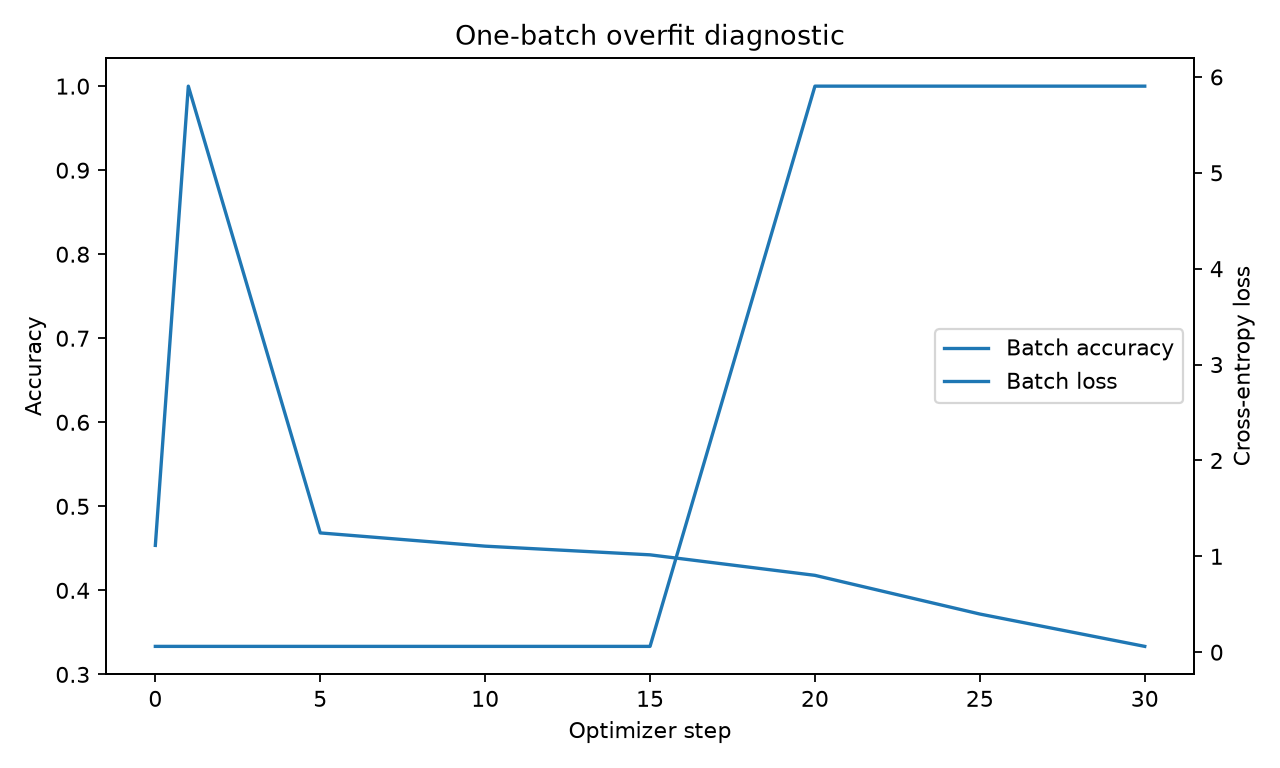

In [3]:
baseline = json.loads((REPORT_ROOT / "baseline_gradient_diagnostic.json").read_text())
overfit = json.loads((REPORT_ROOT / "overfit_result.json").read_text())
print("Baseline diagnostic:", json.dumps(baseline, indent=2))
print("Overfit diagnostic:", json.dumps(overfit, indent=2))
display(Image(filename=str(REPORT_ROOT / "figures" / "overfit_learning_curves.png")))


## FND-005 and FND-006 — Training loop, optimizers, and learning rates


{
  "experiment_id": "FND-005",
  "status": "COMPLETED",
  "training_updates_from": "data/processed/integrated_train.csv",
  "validation_evaluation_from": "data/processed/integrated_validation.csv",
  "validation_weights_unchanged_during_evaluate": true,
  "train_shuffle": true,
  "validation_shuffle": false,
  "early_stopping_enabled": true,
  "validation_macro_f1": 0.2886446886446887,
  "validation_accuracy": 0.38333333333333336,
  "locked_test_csv_files_opened": false,
  "test_split_used": false,
  "final_test_evaluation_authorized": false,
  "production_final_model_changed": false
}


,experiment_id,run_id,variant,status,optimizer,learning_rate,schedule,seed,image_size,sequence_length,...,epochs_completed,best_epoch,training_time_seconds,validation_accuracy,validation_macro_f1,final_train_accuracy,final_train_loss,final_validation_loss,generalization_gap,notes
10,FND-006,fnd006_06_adam_0p0003_seed44,Adam_0.0003_constant_stability_repeat,COMPLETED,Adam,0.0003,NaN,44,24,12,...,7,3,1.255047,0.333333,0.316120,0.322222,1.143194,1.099352,-0.011111,NaN
5,FND-006,fnd006_06_adam_0p0003,Adam_0.0003_constant,COMPLETED,Adam,0.0003,NaN,42,24,12,...,7,3,1.431726,0.366667,0.291582,0.322222,1.126901,1.099604,-0.044444,NaN
7,FND-006,fnd006_08_adamw_0p0003,AdamW_0.0003_constant,COMPLETED,AdamW,0.0003,NaN,42,24,12,...,7,3,1.445161,0.366667,0.291582,0.322222,1.126901,1.099604,-0.044444,NaN
9,FND-006,fnd006_06_adam_0p0003_seed43,Adam_0.0003_constant_stability_repeat,COMPLETED,Adam,0.0003,NaN,43,24,12,...,7,3,1.247726,0.333333,0.281141,0.311111,1.140805,1.099830,-0.022222,NaN
0,FND-006,fnd006_01_sgd_0p01,SGD_0.01_constant,COMPLETED,SGD,0.0100,NaN,42,24,12,...,15,11,1.340185,0.316667,0.255565,0.344444,1.100390,1.100194,0.027778,NaN
1,FND-006,fnd006_02_sgd_0p001,SGD_0.001_constant,COMPLETED,SGD,0.0010,NaN,42,24,12,...,6,2,0.894525,0.333333,0.239892,0.338889,1.121144,1.105154,0.005556,NaN
2,FND-006,fnd006_03_rmsprop_0p001,RMSprop_0.001_constant,COMPLETED,RMSprop,0.0010,NaN,42,24,12,...,10,6,1.367511,0.333333,0.166667,0.305556,1.104018,1.098727,-0.027778,NaN
3,FND-006,fnd006_04_rmsprop_0p0003,RMSprop_0.0003_constant,COMPLETED,RMSprop,0.0003,NaN,42,24,12,...,13,9,1.568762,0.333333,0.166667,0.266667,1.112055,1.100817,-0.066667,NaN
4,FND-006,fnd006_05_adam_0p001,Adam_0.001_constant,COMPLETED,Adam,0.0010,NaN,42,24,12,...,13,9,1.672786,0.333333,0.166667,0.350000,1.097639,1.098543,0.016667,NaN
6,FND-006,fnd006_07_adamw_0p001,AdamW_0.001_constant,COMPLETED,AdamW,0.0010,NaN,42,24,12,...,13,9,1.685568,0.333333,0.166667,0.344444,1.098318,1.098497,0.011111,NaN


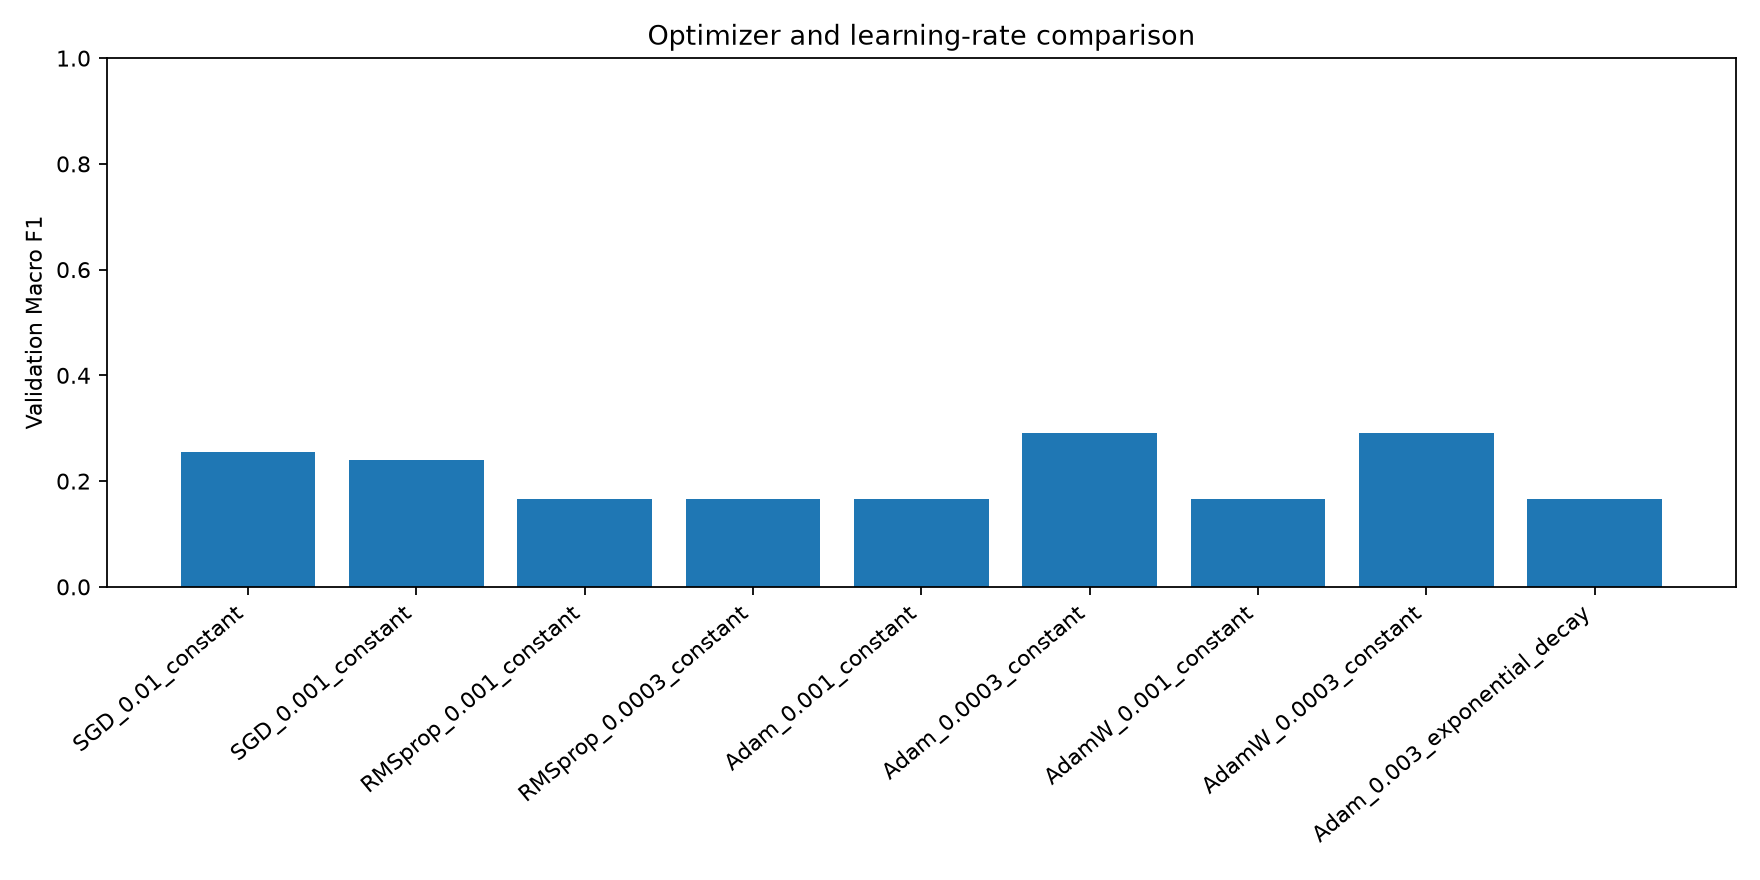

In [4]:
loop_audit = json.loads((REPORT_ROOT / "training_loop_audit.json").read_text())
optimizers = pd.read_csv(REPORT_ROOT / "optimizer_comparison.csv")
print(json.dumps(loop_audit, indent=2))
display(optimizers.sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False))
display(Image(filename=str(REPORT_ROOT / "figures" / "optimizer_macro_f1.png")))


## FND-007 — Model capacity


,experiment_id,run_id,variant,status,optimizer,learning_rate,schedule,seed,image_size,sequence_length,...,epochs_completed,best_epoch,training_time_seconds,validation_accuracy,validation_macro_f1,final_train_accuracy,final_train_loss,final_validation_loss,generalization_gap,notes
0,FND-007,fnd007_small,small,COMPLETED,Adam,0.0003,NaN,42,24,12,...,11,6,2.171589,0.333333,0.289978,0.305556,1.105705,1.099551,-0.027778,NaN
1,FND-007,fnd007_medium,medium,COMPLETED,Adam,0.0003,NaN,42,24,12,...,17,12,3.008798,0.333333,0.305828,0.377778,1.093516,1.098819,0.044444,NaN
2,FND-007,fnd007_large,large,COMPLETED,Adam,0.0003,NaN,42,24,12,...,14,9,2.740263,0.333333,0.254814,0.311111,1.109756,1.098994,-0.022222,NaN


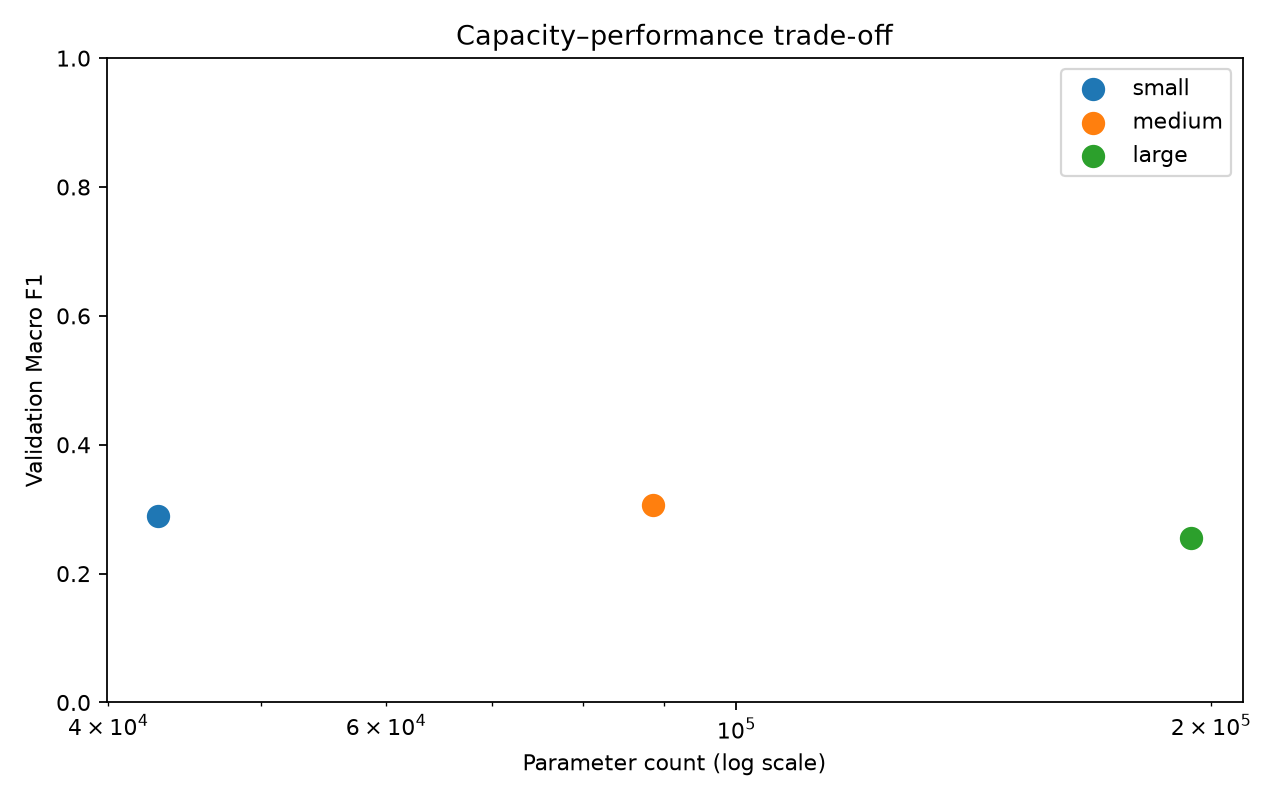

In [5]:
capacity = pd.read_csv(REPORT_ROOT / "capacity_comparison.csv")
display(capacity.sort_values("parameter_count"))
display(Image(filename=str(REPORT_ROOT / "figures" / "capacity_tradeoff.png")))


## FND-008 — Architecture ablation


,experiment_id,run_id,variant,status,optimizer,learning_rate,schedule,seed,image_size,sequence_length,...,epochs_completed,best_epoch,training_time_seconds,validation_accuracy,validation_macro_f1,final_train_accuracy,final_train_loss,final_validation_loss,generalization_gap,notes
7,FND-008,fnd008_08_pretrained_mobilenet_v2,pretrained_mobilenet_v2,COMPLETED,Adam,0.001,NaN,42,96,12,...,7,4,5.539006,0.333333,0.330271,0.305556,1.151523,1.105750,-2.777778e-02,Frozen ImageNet MobileNetV2 feature extractor.
6,FND-008,fnd008_07_cnn_image_branch,cnn_image_branch,COMPLETED,Adam,0.001,NaN,42,24,12,...,6,2,1.477023,0.316667,0.205026,0.305556,1.098723,1.098694,-1.111111e-02,NaN
3,FND-008,fnd008_04_batch_normalization,batch_normalization,COMPLETED,Adam,0.001,NaN,42,24,12,...,5,1,1.396602,0.333333,0.193488,0.294444,1.433950,1.284130,-3.888889e-02,NaN
0,FND-008,fnd008_01_baseline,baseline,COMPLETED,Adam,0.001,NaN,42,24,12,...,13,9,1.758076,0.333333,0.166667,0.350000,1.097639,1.098543,1.666666e-02,NaN
2,FND-008,fnd008_03_dropout_regularization,dropout_regularization,COMPLETED,Adam,0.001,NaN,42,24,12,...,12,8,1.600531,0.333333,0.166667,0.333333,1.102087,1.098797,9.934107e-09,NaN
1,FND-008,fnd008_02_l2_regularization,l2_regularization,COMPLETED,Adam,0.001,NaN,42,24,12,...,24,24,2.674867,0.333333,0.166667,0.333333,1.111602,1.110456,9.934107e-09,NaN
5,FND-008,fnd008_06_learning_rate_schedule,learning_rate_schedule,COMPLETED,Adam,0.003,exponential_decay,42,24,12,...,10,6,1.476154,0.333333,0.166667,0.361111,1.099095,1.098806,2.777777e-02,NaN
4,FND-008,fnd008_05_residual_fusion,residual_fusion,COMPLETED,Adam,0.001,NaN,42,24,12,...,10,6,1.617565,0.333333,0.166667,0.333333,1.099390,1.099178,9.934107e-09,NaN


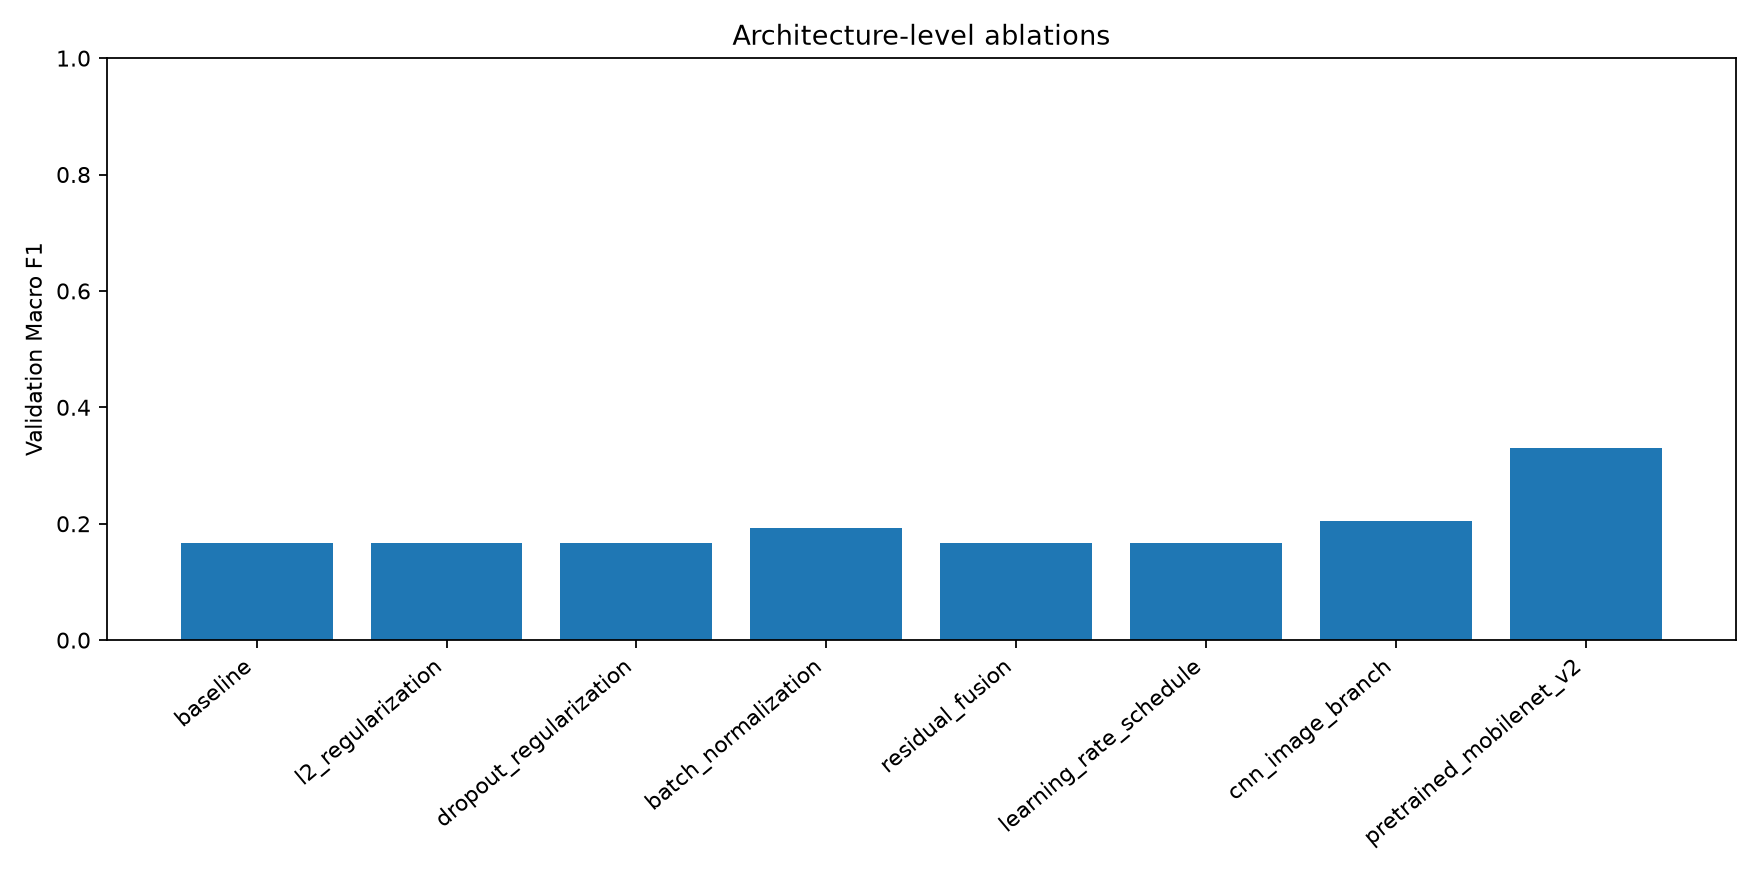

In [6]:
architecture = pd.read_csv(REPORT_ROOT / "architecture_comparison.csv")
display(architecture.sort_values("validation_macro_f1", ascending=False))
display(Image(filename=str(REPORT_ROOT / "figures" / "architecture_comparison.png")))


## FND-009 — Preprocessing alternatives


,experiment_id,run_id,variant,status,optimizer,learning_rate,schedule,seed,image_size,sequence_length,...,epochs_completed,best_epoch,training_time_seconds,validation_accuracy,validation_macro_f1,final_train_accuracy,final_train_loss,final_validation_loss,generalization_gap,notes
3,FND-009,fnd009_04_grayscale_24_seq12,grayscale_24_seq12,COMPLETED,Adam,0.0003,NaN,42,24,12,...,8,4,1.327973,0.333333,0.312593,0.327778,1.105763,1.100749,-0.005556,NaN
2,FND-009,fnd009_03_larger_32_seq20,larger_32_seq20,COMPLETED,Adam,0.0003,NaN,42,32,20,...,7,3,1.321771,0.333333,0.303468,0.288889,1.138389,1.100889,-0.044444,NaN
1,FND-009,fnd009_02_baseline_24_seq12,baseline_24_seq12,COMPLETED,Adam,0.0003,NaN,42,24,12,...,7,3,1.272715,0.366667,0.291582,0.322222,1.126901,1.099604,-0.044444,NaN
0,FND-009,fnd009_01_compact_16_seq8,compact_16_seq8,COMPLETED,Adam,0.0003,NaN,42,16,8,...,12,8,1.633185,0.333333,0.274094,0.322222,1.108132,1.099164,-0.011111,NaN


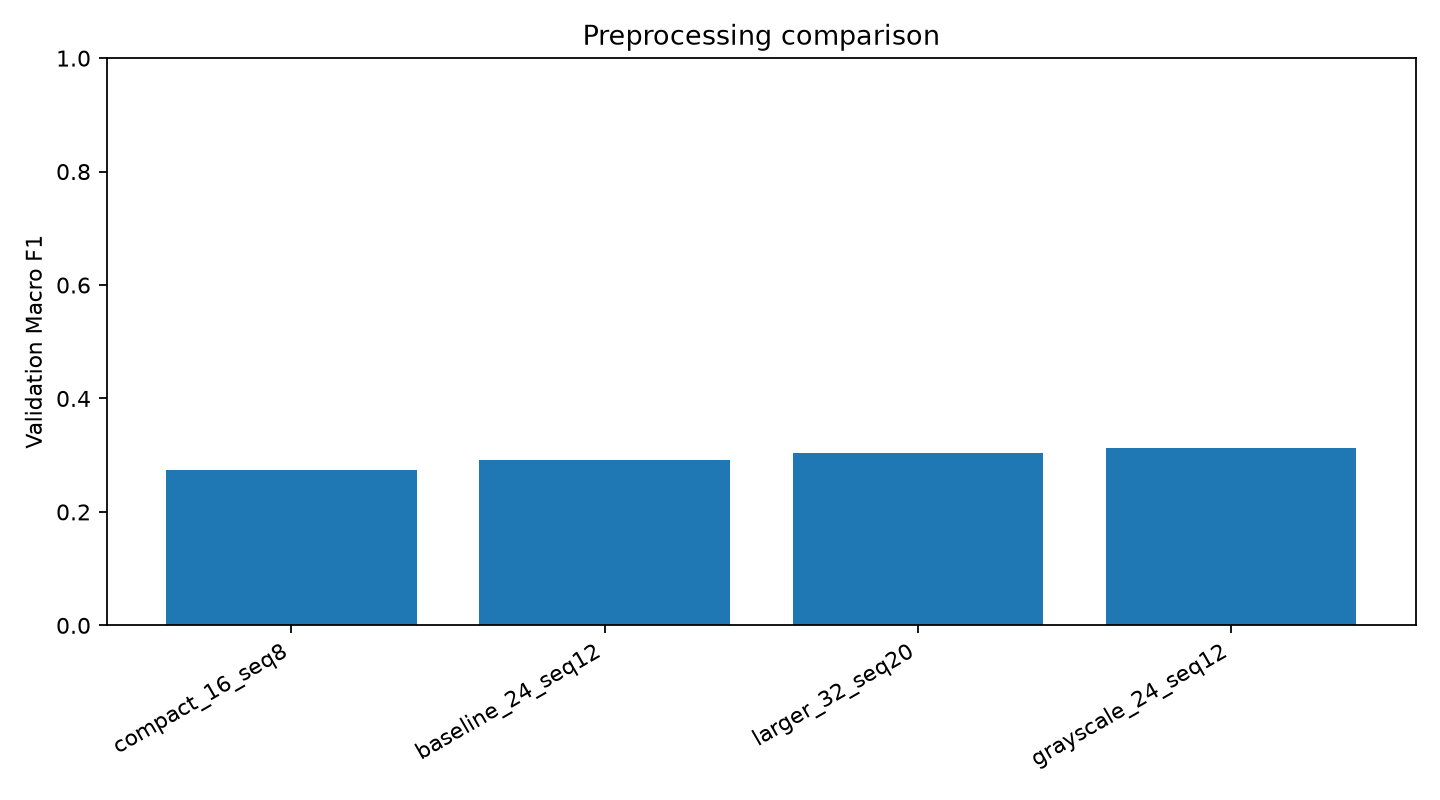

In [7]:
preprocessing = pd.read_csv(REPORT_ROOT / "preprocessing_comparison.csv")
display(preprocessing.sort_values("validation_macro_f1", ascending=False))
display(Image(filename=str(REPORT_ROOT / "figures" / "preprocessing_comparison.png")))


## FND-010 — Controlled failure diagnostics


,case,status,metric_name,metric_value,signature_detected,observation,prevention
0,unscaled_images,OBSERVED,validation_macro_f1,1.666667e-01,True,Validation Macro F1=0.1667 versus the correct-...,Keep explicit image scaling in the model and a...
1,excessive_learning_rate,OBSERVED,validation_macro_f1,1.666667e-01,True,Validation Macro F1=0.1667 versus the correct-...,Use bounded predefined learning rates and term...
2,tiny_learning_rate,OBSERVED,validation_macro_f1,2.558008e-01,True,Validation Macro F1=0.2558 versus the correct-...,Track loss reduction and reject configurations...
3,excessive_dropout,OBSERVED,validation_macro_f1,1.666667e-01,True,Validation Macro F1=0.1667 versus the correct-...,Treat dropout as a tuned regularizer rather th...
4,misaligned_train_labels,OBSERVED,validation_macro_f1,2.667734e-01,True,Validation Macro F1=0.2668 versus the correct-...,Verify sample IDs and labels before every shuf...
5,sigmoid_activation,NO_STRONG_SIGNATURE,validation_macro_f1,2.401961e-01,False,Validation Macro F1=0.2402 versus the correct-...,Compare timing and gradients; prefer ReLU-like...
6,deep_sigmoid_gradient_probe,OBSERVED,first_to_last_kernel_gradient_ratio,6.806216e-07,True,Deep sigmoid networks can produce strongly une...,"Prefer ReLU-like activations, normalization, a..."
7,missing_optimizer_step_probe,OBSERVED,absolute_loss_change_without_update,9.859562e-02,True,Repeated forward passes without an optimizer u...,Use model.fit/train_on_batch or a reviewed cus...
8,validation_training_blocked,BLOCKED_BY_DESIGN,validation_used_for_weight_updates,0.000000e+00,True,The suite exposes fixed train and validation a...,Keep the split paths fixed in configuration an...


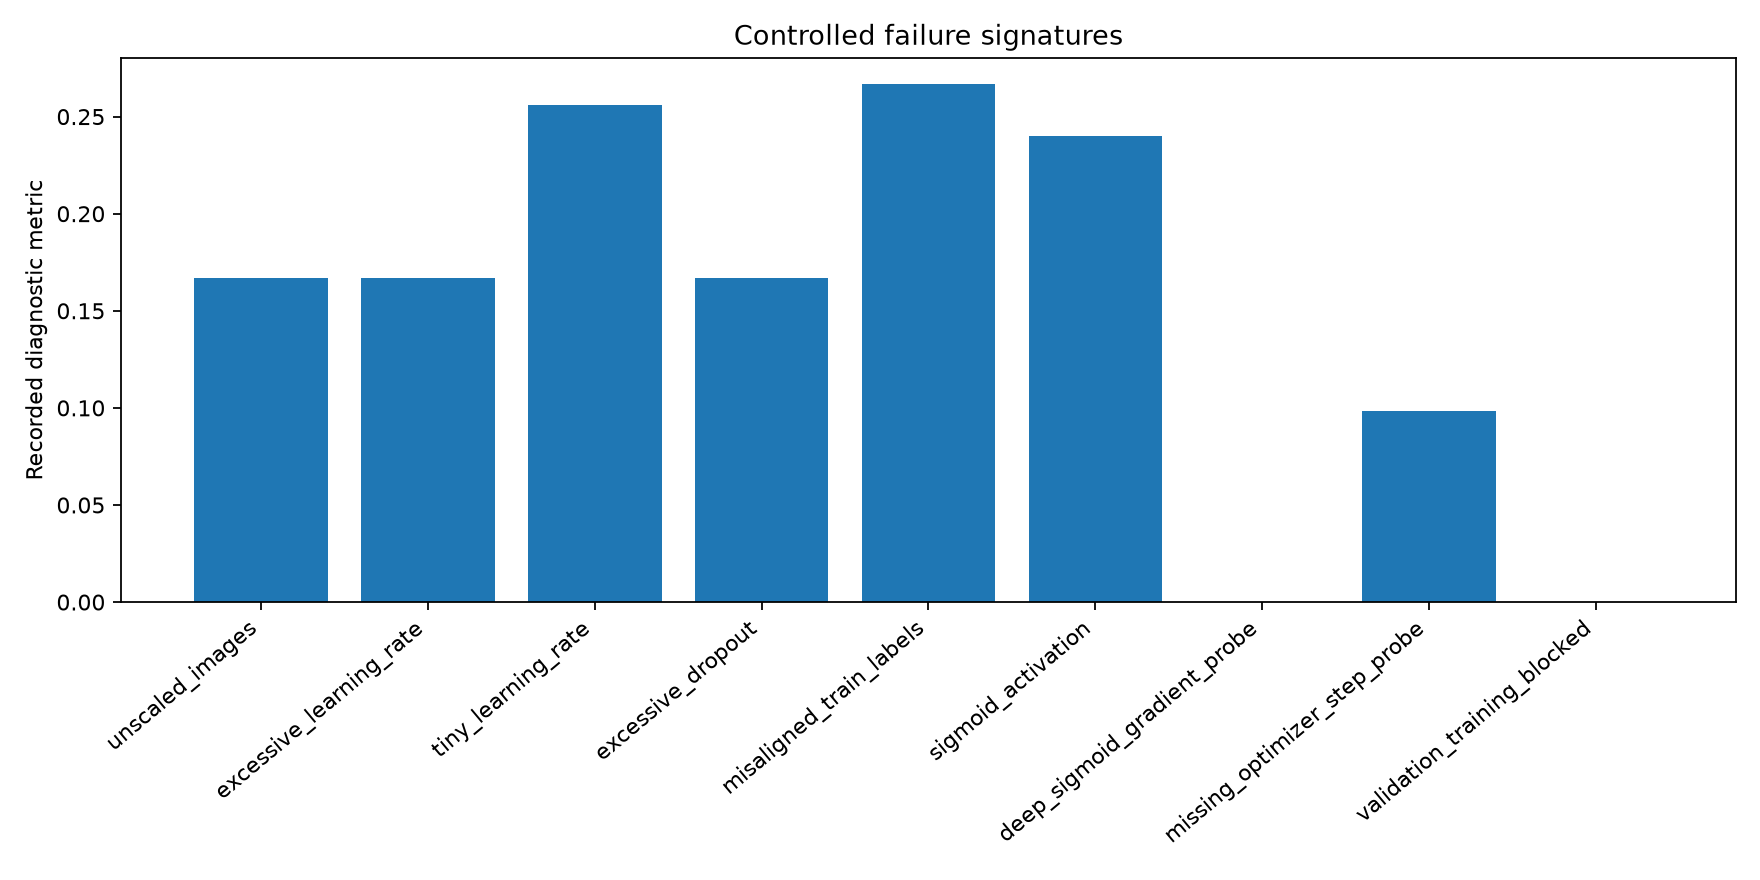

In [8]:
failures = pd.read_csv(REPORT_ROOT / "failure_diagnostics.csv")
display(failures)
display(Image(filename=str(REPORT_ROOT / "figures" / "failure_signatures.png")))


## Synthesis and locked evaluation status


In [9]:
status = json.loads((REPORT_ROOT / "fundamentals_suite_status.json").read_text())
comparison = pd.read_csv(REPORT_ROOT / "experiment_comparison.csv")
print(json.dumps(status, indent=2))
cols = ["experiment_id", "variant", "validation_accuracy", "validation_macro_f1", "parameter_count", "training_time_seconds"]
display(comparison[cols].sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False).head(15))
assert status["test_split_used"] is False
assert status["final_test_evaluation_authorized"] is False


{
  "schema_version": "1.0",
  "step": "011.1",
  "status": "PASS",
  "readiness": "FUNDAMENTALS_EXPERIMENTAL_SUITE_COMPLETE_TEST_LOCKED",
  "base_checkpoint": "STEP_011_0_FULL_COURSE_COVERAGE_ARCHITECTURE",
  "base_commit": "58d6236",
  "exercise_problem_count": 10,
  "completed_exercise_problem_count": 10,
  "model_training_performed": true,
  "model_selection_changed": false,
  "educational_validation_champions_recorded": true,
  "run_count": 35,
  "completed_run_count": 35,
  "diagnostic_failure_run_count": 0,
  "resource_skip_run_count": 0,
  "optimizer_champion_run_id": "fnd006_06_adam_0p0003",
  "notebook_executed": true,
  "notebook_error_outputs": 0,
  "python_version": "3.13.13",
  "locked_test_csv_files_opened": false,
  "test_split_used": false,
  "final_test_evaluation_authorized": false,
  "production_final_model_changed": false
}


,experiment_id,variant,validation_accuracy,validation_macro_f1,parameter_count,training_time_seconds
24,FND-008,pretrained_mobilenet_v2,0.333333,0.330271,2325099,5.539006
13,FND-006,Adam_0.0003_constant_stability_repeat,0.333333,0.316120,88619,1.255047
28,FND-009,grayscale_24_seq12,0.333333,0.312593,33323,1.327973
15,FND-007,medium,0.333333,0.305828,88619,3.008798
27,FND-009,larger_32_seq20,0.333333,0.303468,153131,1.321771
8,FND-006,Adam_0.0003_constant,0.366667,0.291582,88619,1.431726
10,FND-006,AdamW_0.0003_constant,0.366667,0.291582,88619,1.445161
26,FND-009,baseline_24_seq12,0.366667,0.291582,88619,1.272715
14,FND-007,small,0.333333,0.289978,43015,2.171589
2,FND-005,correct_training_validation_loop,0.383333,0.288645,88619,2.716308


## Conclusion

The suite demonstrates data contracts, gradient flow, deliberate one-batch
overfitting, a correct train/validation loop, optimizer and learning-rate
comparisons, capacity control, regularization and architectural ablations,
preprocessing alternatives, and safe failure diagnostics. These experiments
are educational comparisons; they do not replace or modify the frozen final
exam model from Step 010.8.
